# 1D periodic checkerboard

In [1]:
%reset -f
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
from pathlib import Path
from src.dataLib.synthetic import Checkerboard_Dataset, TorusLieWrapper, AngleTorusWrapper, torus_embedding
from torch.utils.data import DataLoader
from matplotlib import patches
import src.plot as custom_plot

Get samples from the 1D-Periodic checkerboard dataset

In [2]:
n_rows = 4
batch_size = 10000
dim = 1

checkerboard_dataset = Checkerboard_Dataset(n_rows, dataset_size=100000, dim = dim)


loader = DataLoader(checkerboard_dataset, batch_size=batch_size, shuffle = True)
batch = next(iter(loader))
# first_sample = batch[0]
print("sample shape of checkerboard dataset", batch.shape)

sample shape of checkerboard dataset torch.Size([10000, 1])


## Flat and embedded views

The one-dimensional flat torus is $T^1 = \mathbb{R}/\mathbb{Z}$, represented below by $[0,1)$ with $0 \equiv 1$. It is topologically a circle. The embedding

$$x \mapsto (\cos\theta, \sin\theta), \qquad \theta = 2\pi(x-1/2),$$

maps the same periodic checkerboard onto $S^1 \subset \mathbb{R}^2$. Matching colors show how every flat tile becomes an arc of the circle.

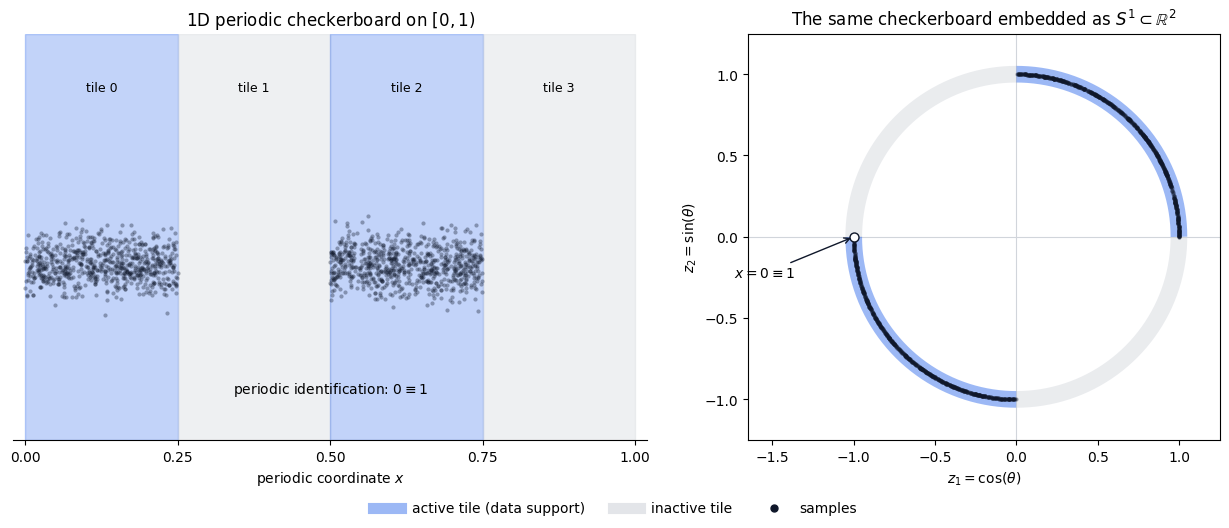

In [3]:
# Use the same tile colors in the flat and embedded views.
active_color = "#2563eb"
inactive_color = "#d1d5db"
sample_color = "#0f172a"

x_samples = batch[:, 0].detach().cpu().numpy()
rng = np.random.default_rng(0)
n_to_show = min(1500, len(x_samples))
shown = rng.choice(x_samples, size=n_to_show, replace=False)

fig, (ax_flat, ax_circle) = plt.subplots(
    1, 2, figsize=(13, 5.2), constrained_layout=True
)

# Flat representation: alternating tiles on [0, 1), with 0 and 1 identified.
tile_edges = np.linspace(0.0, 1.0, n_rows + 1)
for tile, (left, right) in enumerate(zip(tile_edges[:-1], tile_edges[1:])):
    is_active = tile % 2 == 0
    ax_flat.axvspan(
        left, right,
        color=active_color if is_active else inactive_color,
        alpha=0.28 if is_active else 0.35,
        zorder=0,
    )
    ax_flat.text(
        (left + right) / 2, 0.13,
        f"tile {tile}", ha="center", va="center", fontsize=9
    )

jitter = rng.normal(loc=0.0, scale=0.012, size=n_to_show)
ax_flat.scatter(shown, jitter, s=9, color=sample_color, alpha=0.35, linewidths=0)
ax_flat.text(0.5, -0.095, r"periodic identification: $0 \equiv 1$", ha="center")
ax_flat.set(
    xlim=(-0.02, 1.02), ylim=(-0.13, 0.17),
    xlabel=r"periodic coordinate $x$",
    title="1D periodic checkerboard on $[0,1)$",
)
ax_flat.set_xticks(tile_edges)
ax_flat.set_yticks([])
ax_flat.spines[["left", "right", "top"]].set_visible(False)

# S^1 embedding: theta = 2*pi*(x - 1/2), then x -> (cos(theta), sin(theta)).
for tile, (left, right) in enumerate(zip(tile_edges[:-1], tile_edges[1:])):
    theta_tile = np.linspace(
        2 * np.pi * (left - 0.5),
        2 * np.pi * (right - 0.5),
        200,
    )
    is_active = tile % 2 == 0
    ax_circle.plot(
        np.cos(theta_tile), np.sin(theta_tile),
        color=active_color if is_active else inactive_color,
        linewidth=12, alpha=0.45, solid_capstyle="butt", zorder=1,
    )

theta_samples = 2 * np.pi * (shown - 0.5)
ax_circle.scatter(
    np.cos(theta_samples), np.sin(theta_samples),
    s=9, color=sample_color, alpha=0.35, linewidths=0, zorder=2,
)
ax_circle.scatter([-1], [0], s=42, facecolor="white", edgecolor=sample_color, zorder=3)
ax_circle.annotate(
    r"$x=0 \equiv 1$", xy=(-1, 0), xytext=(-1.55, -0.25),
    arrowprops={"arrowstyle": "->", "color": sample_color},
    ha="center",
)
ax_circle.axhline(0, color=inactive_color, linewidth=0.8, zorder=0)
ax_circle.axvline(0, color=inactive_color, linewidth=0.8, zorder=0)
ax_circle.set(
    aspect="equal", xlim=(-1.65, 1.25), ylim=(-1.25, 1.25),
    xlabel=r"$z_1=\cos(\theta)$", ylabel=r"$z_2=\sin(\theta)$",
    title=r"The same checkerboard embedded as $S^1 \subset \mathbb{R}^2$",
)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=active_color, lw=8, alpha=0.45, label="active tile (data support)"),
    Line2D([0], [0], color=inactive_color, lw=8, alpha=0.6, label="inactive tile"),
    Line2D([0], [0], marker="o", linestyle="none", color=sample_color, markersize=5, label="samples"),
]
fig.legend(handles=legend_handles, loc="outside lower center", ncol=3, frameon=False)
plt.show()